In [2]:
#Test the libraries

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import xgboost as xgb
import shap

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the modeling table

df = pd.read_parquet(
    'data/processed/modeling_table.parquet'
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 24


In [4]:
#Check the data

df.head()

,customer_id,first_purchase,last_purchase,total_orders,total_spend,avg_order_value,recent_90d_orders,prior_90d_orders,preferred_channel,tenure_days,...,Active,club_member_status,fashion_news_frequency,age,postal_code,usage_change_pct,customer_satisfaction_score,complaints_last_60_days,support_tickets,payment_failures
0,6b76f530c64a43f194f32051291e573cb274c9a7cd0c2a...,2018-09-26,2019-05-28,9,0.132729,0.014748,0,0,1,607,...,1.0,ACTIVE,Regularly,33.0,75c4921a65f14b3ca2f7b741258171c84fedb5b87566bd...,0.0,6.0,0,0,0
1,d5d78cc39dba1e3096a39337487e6953f3a88ccdba5a18...,2018-12-14,2018-12-14,1,0.091508,0.091508,0,0,1,528,...,0.0,ACTIVE,Regularly,28.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...,0.0,5.4,1,1,0
2,8cae5ce5bbd2cb6dc7a4315309c88ce1e5c7fcf4818a5b...,2019-10-24,2020-05-17,10,0.333729,0.033373,7,0,2,214,...,0.0,PRE-CREATE,NONE,33.0,47e3ff3b34ab1c2450822a47b85bbdf6316aa5b8487c3e...,200.0,8.1,1,1,0
3,61b32813f52495f84f70537e414517360687899b5cedba...,2019-11-16,2019-11-27,10,0.485424,0.048542,0,0,2,191,...,1.0,ACTIVE,Regularly,57.0,b031a69e442f52fd966ed97584dbe53a3115cfdfafa8a1...,0.0,7.5,1,1,0
4,65b51ae24c0d98a9e9d322fa4b3ae733ee8726c8dee54e...,2019-12-01,2019-12-01,3,0.078339,0.026113,0,3,2,176,...,1.0,ACTIVE,Regularly,62.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...,-100.0,3.8,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   customer_id                  100000 non-null  str           
 1   first_purchase               100000 non-null  datetime64[us]
 2   last_purchase                100000 non-null  datetime64[us]
 3   total_orders                 100000 non-null  int64         
 4   total_spend                  100000 non-null  float64       
 5   avg_order_value              100000 non-null  float64       
 6   recent_90d_orders            100000 non-null  int64         
 7   prior_90d_orders             100000 non-null  int64         
 8   preferred_channel            100000 non-null  int64         
 9   tenure_days                  100000 non-null  int64         
 10  days_since_last_purchase     100000 non-null  int64         
 11  churn                        100000 no

In [6]:
df['churn'].value_counts()

churn
1    59199
0    40801
Name: count, dtype: int64

In [7]:
df['churn'].value_counts(normalize=True)

churn
1    0.59199
0    0.40801
Name: proportion, dtype: float64

In [8]:
# Define feature columns

numeric_cols = [
    'total_orders',
    'total_spend',
    'avg_order_value',
    'recent_90d_orders',
    'prior_90d_orders',
    'tenure_days',
    'days_since_last_purchase',
    'category_diversity',
    'FN',
    'Active',
    'age',
    'usage_change_pct',
    'customer_satisfaction_score',
    'complaints_last_60_days',
    'support_tickets',
    'payment_failures',
    'preferred_channel'
]

categorical_cols = [
    'club_member_status',
    'fashion_news_frequency'
]

In [9]:
# Check for missing columns

required_cols = numeric_cols + categorical_cols + ['churn', 'customer_id']

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

print("Missing columns:", missing_cols)

Missing columns: []


In [10]:
# Create the modeling datasets/table converts categorical variables into numeric dummy variables
# This is necessary because machine-learning models need numerical inputs

model_df = pd.get_dummies(
    df[numeric_cols + categorical_cols + ['churn', 'customer_id']],
    columns=categorical_cols,
    drop_first=True
)

print("Modeling table shape:", model_df.shape)

Modeling table shape: (100000, 24)


In [11]:
# Split the data into features (X) and target (y)
# X These are the variables used to predict churn
# y This is the thing we're predicting


X = model_df.drop(
    columns=['churn', 'customer_id']
)

y = model_df['churn']

ids = model_df['customer_id']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 22)
y shape: (100000,)


In [12]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

In [13]:
# Split the data into training and testing sets

# we'll divide our customers into: 80% training and 20% testing
# The test set is important because we haven't allowed the models to learn from it
# That gives us a more honest comparison


X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    ids,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 80000
Testing customers: 20000


In [14]:
# Model 1: Logistic Regression
# Scale the numeric features

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [15]:
# Train the logistic regression model

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_s, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [16]:
# Get Logistic Regression probabilities for the test set
# Probabilities are the model's confidence that a customer will churn. A probability of 0.8 means the model is 80% confident that the customer will churn.


logreg_probs = logreg.predict_proba(X_test_s)[:, 1]

print(logreg_probs[:10])

[0.78465055 0.93445528 0.90656812 0.66234544 0.75587688 0.9144232
 0.46795122 0.8472971  0.92435399 0.96487408]


In [17]:
import xgboost as xgb

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [48]:
# Model 2: XGBoost
# Now we're going to train a more powerful model

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)

In [49]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [50]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [20]:
# Get XGBoost probabilities for the test set

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(xgb_probs[:10])

[0.7782976  0.9083973  0.9503757  0.56186205 0.83011395 0.8892631
 0.38226637 0.84739834 0.9306183  0.8933191 ]


In [21]:
# Evaluation function

def evaluate(name, y_true, probs):
    
    preds = (probs >= 0.5).astype(int)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("ROC-AUC:",
          round(roc_auc_score(y_true, probs), 4))

    print("PR-AUC:",
          round(average_precision_score(y_true, probs), 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            preds,
            digits=3
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_true,
            preds
        )
    )

In [22]:
# Evaluate Logistic Regression

evaluate(
    "Logistic Regression",
    y_test,
    logreg_probs
)

Logistic Regression
ROC-AUC: 0.8372
PR-AUC: 0.8696

Classification Report:
              precision    recall  f1-score   support

           0      0.731     0.680     0.704      8160
           1      0.789     0.828     0.808     11840

    accuracy                          0.767     20000
   macro avg      0.760     0.754     0.756     20000
weighted avg      0.766     0.767     0.766     20000

Confusion Matrix:
[[5547 2613]
 [2042 9798]]


In [23]:
# Evaluate XGBoost

evaluate(
    "XGBoost",
    y_test,
    xgb_probs
)

XGBoost
ROC-AUC: 0.8424
PR-AUC: 0.8759

Classification Report:
              precision    recall  f1-score   support

           0      0.737     0.682     0.708      8160
           1      0.791     0.832     0.811     11840

    accuracy                          0.771     20000
   macro avg      0.764     0.757     0.760     20000
weighted avg      0.769     0.771     0.769     20000

Confusion Matrix:
[[5562 2598]
 [1988 9852]]


In [24]:
# Compare the two models

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'XGBoost'
    ],
    
    'ROC_AUC': [
        roc_auc_score(y_test, logreg_probs),
        roc_auc_score(y_test, xgb_probs)
    ],
    
    'PR_AUC': [
        average_precision_score(y_test, logreg_probs),
        average_precision_score(y_test, xgb_probs)
    ]
})

comparison['ROC_AUC'] = comparison['ROC_AUC'].round(4)
comparison['PR_AUC'] = comparison['PR_AUC'].round(4)

comparison

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.8372,0.8696
1,XGBoost,0.8424,0.8759


In [25]:
# Determine the winning model

winning_model = xgb_model
winning_probs = xgb_probs

print("Winner: XGBoost")

Winner: XGBoost


In [26]:
# SHAP for XGBoost
# SHAP (SHapley Additive exPlanations) explains why XGBoost made a particular prediction


explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP calculation completed!")

SHAP calculation completed!


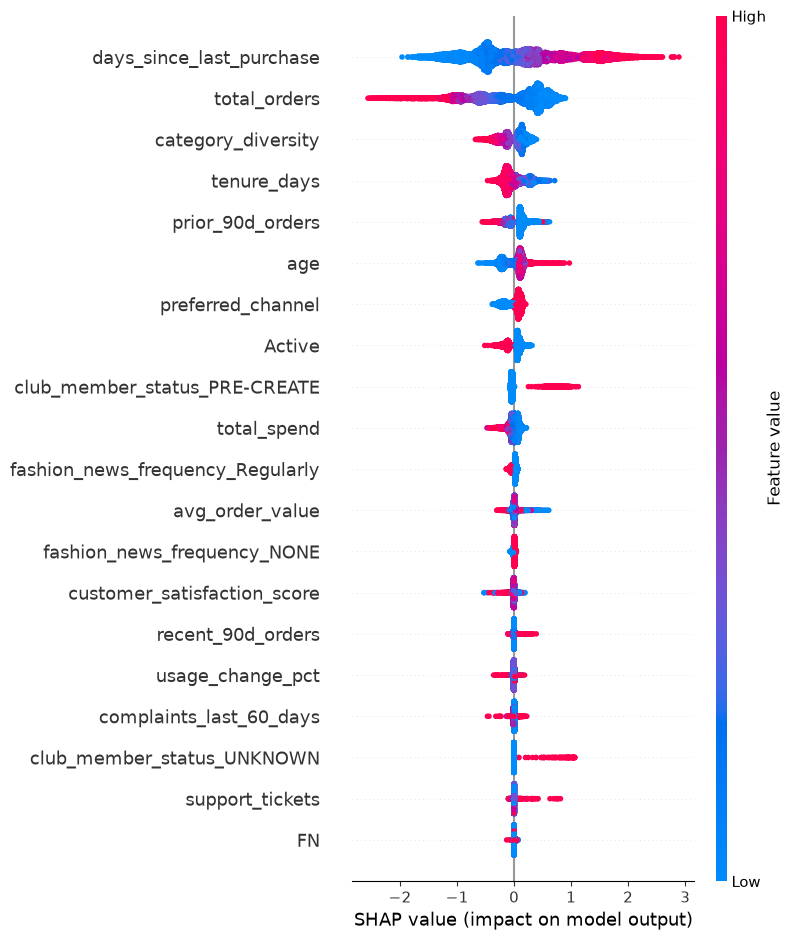

In [27]:
# Visualize SHAP values
# Global SHAP explanation this gives us the answer to: Which variables are most important in predicting customer churn?

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

In [28]:
# Local SHAP explanation this gives us the answer to: Why did XGBoost predict that a particular customer would churn?

def top_reasons(row_position, n=3):
    
    contributions = pd.Series(
        shap_values[row_position],
        index=X_test.columns
    )
    
    return (
        contributions
        .reindex(
            contributions.abs()
            .sort_values(ascending=False)
            .index
        )
        .head(n)
    )

In [29]:
# Example: Get the top 3 reasons for the first customer in the test set


top_reasons(0)

tenure_days                 0.249485
days_since_last_purchase    0.210726
total_orders                0.198351
dtype: float32

In [30]:
# Create the customer risk table
# Create a results table with customer_id, actual churn, and predicted churn probability

results = X_test.copy()

results['customer_id'] = id_test.values

results['churn_actual'] = y_test.values

results['churn_prob'] = xgb_probs

In [31]:
# Add customer value to the results table

customer_values = (
    df[['customer_id', 'total_spend']]
    .drop_duplicates('customer_id')
)

results = results.merge(
    customer_values,
    on='customer_id',
    how='left'
)

results = results.rename(
    columns={
        'total_spend': 'customer_value'
    }
)

In [32]:
print(results.columns.tolist())

['total_orders', 'total_spend_x', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'customer_id', 'churn_actual', 'churn_prob', 'total_spend_y']


In [33]:
print(df.columns.tolist())

['customer_id', 'first_purchase', 'last_purchase', 'total_orders', 'total_spend', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'preferred_channel', 'tenure_days', 'days_since_last_purchase', 'churn', 'category_diversity', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures']


In [34]:
# Get one customer value per customer


customer_values = (
    df[['customer_id', 'total_spend']]
    .drop_duplicates('customer_id')
    .rename(columns={'total_spend': 'customer_value'})
)

# Add customer value to prediction results
results = results.merge(
    customer_values,
    on='customer_id',
    how='left'
)

# Check columns
print(results.columns.tolist())

['total_orders', 'total_spend_x', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'customer_id', 'churn_actual', 'churn_prob', 'total_spend_y', 'customer_value']


In [35]:
# Display the results table with customer_id, churn probability, and customer value

results[
    ['customer_id', 'churn_prob', 'customer_value']
].head(10)

,customer_id,churn_prob,customer_value
0,de6066796e7c487ac8f560a0054a2d33f46670665f7022...,0.778298,0.212593
1,8186e3047b978482c2dd88a59d32ea4a5b35ba1554d398...,0.908397,0.088102
2,894a884596ec545e5e5753289d7d8cb99f6f87c8ba2943...,0.950376,0.089915
3,5816c90c4f6a80ecbfeda890f1b859bcf5b738ee7d9876...,0.561862,0.159339
4,cc08fa6a59c37407b7dc2e9b8f3bc18d34eaa99e190884...,0.830114,2.095373
5,b3fff42175da7f9522341f0616bbe2bdd81d8cb25faa05...,0.889263,0.042305
6,3bc5ad606e04e6c80bb60fcaa24a9030e23ad27457f824...,0.382266,0.124814
7,33d3e45946ce6fade83636cfbed377ac59d5df1a6d37ba...,0.847398,0.077729
8,7429801b6760b941380e817de9fbc1a6d999c8e8829453...,0.930618,0.033881
9,cc780e242d35a555d2d62a5da34f80bde0ad9c2e960270...,0.893319,0.025407


In [36]:
# Check the columns in the results and customer_values DataFrames

print("Results columns:")
print(results.columns.tolist())

print("\nCustomer values columns:")
print(customer_values.columns.tolist())

print("\nSample results:")
print(results.head())

print("\nSample customer values:")
print(customer_values.head())

Results columns:
['total_orders', 'total_spend_x', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'customer_id', 'churn_actual', 'churn_prob', 'total_spend_y', 'customer_value']

Customer values columns:
['customer_id', 'customer_value']

Sample results:
   total_orders  total_spend_x  avg_order_value  recent_90d_orders  \
0             7       0.212593         0.030370                  0   
1             2       0.088102         0.044051                  0   
2             5       0.089915         0.017983                  0   
3            17       0.159339         0.009373                 

In [37]:
# Get one customer value per customer

customer_values = (
    df[['customer_id', 'total_spend']]
    .drop_duplicates('customer_id')
    .rename(columns={'total_spend': 'customer_value'})
)

In [38]:
print(results.columns.tolist())
print(df.columns.tolist())

['total_orders', 'total_spend_x', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'customer_id', 'churn_actual', 'churn_prob', 'total_spend_y', 'customer_value']
['customer_id', 'first_purchase', 'last_purchase', 'total_orders', 'total_spend', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'preferred_channel', 'tenure_days', 'days_since_last_purchase', 'churn', 'category_diversity', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures'

In [39]:
# Check for duplicate columns in the results DataFrame

results = results.drop(
    columns=['total_spend_x', 'total_spend_y'],
    errors='ignore'
)

In [40]:
print(results.columns.tolist())

['total_orders', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'customer_id', 'churn_actual', 'churn_prob', 'customer_value']


In [41]:

results[
    ['customer_id', 'churn_prob', 'customer_value']
].head()

,customer_id,churn_prob,customer_value
0,de6066796e7c487ac8f560a0054a2d33f46670665f7022...,0.778298,0.212593
1,8186e3047b978482c2dd88a59d32ea4a5b35ba1554d398...,0.908397,0.088102
2,894a884596ec545e5e5753289d7d8cb99f6f87c8ba2943...,0.950376,0.089915
3,5816c90c4f6a80ecbfeda890f1b859bcf5b738ee7d9876...,0.561862,0.159339
4,cc08fa6a59c37407b7dc2e9b8f3bc18d34eaa99e190884...,0.830114,2.095373


In [42]:
# Estimated conversion factor for business interpretation
# IMPORTANT: This is an estimate, NOT officially disclosed H&M revenue data.

PRICE_SCALE_ESTIMATE = 590

results['customer_value_est'] = (
    results['customer_value'] * PRICE_SCALE_ESTIMATE
)

In [43]:
# Original normalized revenue at risk
results['revenue_at_risk'] = (
    results['churn_prob'] *
    results['customer_value']
)

# Estimated business-value revenue at risk
results['revenue_at_risk_est'] = (
    results['churn_prob'] *
    results['customer_value_est']
)

In [44]:
# Display the results table with customer_id, churn probability, customer value, estimated customer value, revenue_at_risk and estimated revenue at risk
# These are estimated business-value units, not verified H&M dollars.
results[
    [
        'customer_id',
        'churn_prob',
        'customer_value',
        'customer_value_est',
        'revenue_at_risk',
        'revenue_at_risk_est'
    ]
].head(10)

,customer_id,churn_prob,customer_value,customer_value_est,revenue_at_risk,revenue_at_risk_est
0,de6066796e7c487ac8f560a0054a2d33f46670665f7022...,0.778298,0.212593,125.43,0.165461,97.621868
1,8186e3047b978482c2dd88a59d32ea4a5b35ba1554d398...,0.908397,0.088102,51.98,0.080031,47.218493
2,894a884596ec545e5e5753289d7d8cb99f6f87c8ba2943...,0.950376,0.089915,53.05,0.085453,50.417430
3,5816c90c4f6a80ecbfeda890f1b859bcf5b738ee7d9876...,0.561862,0.159339,94.01,0.089527,52.820651
4,cc08fa6a59c37407b7dc2e9b8f3bc18d34eaa99e190884...,0.830114,2.095373,1236.27,1.739398,1026.244970
5,b3fff42175da7f9522341f0616bbe2bdd81d8cb25faa05...,0.889263,0.042305,24.96,0.037620,22.196007
6,3bc5ad606e04e6c80bb60fcaa24a9030e23ad27457f824...,0.382266,0.124814,73.64,0.047712,28.150096
7,33d3e45946ce6fade83636cfbed377ac59d5df1a6d37ba...,0.847398,0.077729,45.86,0.065867,38.861688
8,7429801b6760b941380e817de9fbc1a6d999c8e8829453...,0.930618,0.033881,19.99,0.031531,18.603060
9,cc780e242d35a555d2d62a5da34f80bde0ad9c2e960270...,0.893319,0.025407,14.99,0.022696,13.390853


In [45]:
# Calculate revenue at risk
# Estimated conversion factor for business interpretation

PRICE_SCALE_ESTIMATE = 590

results['customer_value_est'] = (
    results['customer_value'] * PRICE_SCALE_ESTIMATE
)

results['revenue_at_risk_est'] = (
    results['revenue_at_risk'] * PRICE_SCALE_ESTIMATE
)

In [46]:
print(
    "Total revenue at risk:",
    round(
        results['revenue_at_risk'].sum(),
        2
    )
)

Total revenue at risk: 3330.87


In [47]:
# Get the customer's total spend

customer_total_spend = X_test.iloc[
    customer_index
]["total_spend"]

# Calculate expected revenue at risk

revenue_at_risk = (
    customer_total_spend * customer_probability
)

print("Customer total spend:", customer_total_spend)
print("Churn probability:", f"{customer_probability:.2%}")
print(
    "Expected revenue at risk:",
    f"{revenue_at_risk:,.2f}"
)

NameError: name 'customer_index' is not defined

In [ ]:
# Create risk segments
# Calculate the median customer value

value_median = results['customer_value'].median()

In [ ]:
prob_median = results['churn_prob'].median()

In [ ]:
print("Median customer value:", value_median)
print("Median churn probability:", prob_median)

Median customer value: 0.23544067796610169
Median churn probability: 0.6433644


In [ ]:
# Create the four segments
# Define a function to segment customers based on churn probability and customer value

def segment(r):
    
    high_probability = (
        r['churn_prob'] >= prob_median
    )
    
    high_value = (
        r['customer_value'] >= value_median
    )

    if high_probability and high_value:
        return 'Critical - Immediate Action'
    
    if high_probability and not high_value:
        return 'Low-cost automation'
    
    if not high_probability and high_value:
        return 'Loyalty building'
    
    return 'Standard engagement'

In [ ]:
results['segment'] = results.apply(
    segment,
    axis=1
)

In [ ]:
# Display the each segment counts

results['segment'].value_counts()

segment
Low-cost automation            8338
Loyalty building               8338
Standard engagement            1662
Critical - Immediate Action    1662
Name: count, dtype: int64

In [ ]:
# Revenue at risk by segment
# Create a summary table for each segment

segment_summary = (
    results
    .groupby('segment')
    .agg(
        customers=('customer_id', 'count'),
        total_customer_value=('customer_value', 'sum'),
        revenue_at_risk=('revenue_at_risk', 'sum'),
        avg_churn_probability=('churn_prob', 'mean')
    )
    .sort_values(
        'revenue_at_risk',
        ascending=False
    )
)

segment_summary

,customers,total_customer_value,revenue_at_risk,avg_churn_probability
segment,,,,
Loyalty building,8338,10350.474000,2002.516257,0.296729
Low-cost automation,8338,736.984610,619.148422,0.852225
Critical - Immediate Action,1662,734.016593,580.937976,0.797256
Standard engagement,1662,253.996373,128.264069,0.513188


In [ ]:
# Display the top 500 customers by revenue at risk

top_500 = (
    results
    .sort_values(
        'revenue_at_risk',
        ascending=False
    )
    .head(500)
)

In [ ]:
print(
    "Customers selected:",
    len(top_500)
)

Customers selected: 500


In [ ]:
# Calculate the total revenue at risk covered by the top 500 customers

revenue_covered = top_500[
    'revenue_at_risk'
].sum()

print(
    "Revenue at risk covered by top 500:",
    round(revenue_covered, 2)
)

Revenue at risk covered by top 500: 454.55


In [ ]:
# Calculate the percentage of total revenue at risk for all customers

total_risk = results[
    'revenue_at_risk'
].sum()

risk_coverage = (
    revenue_covered /
    total_risk
) * 100

print(
    "Top 500 risk coverage:",
    round(risk_coverage, 2),
    "%"
)

Top 500 risk coverage: 13.65 %


In [ ]:
# Save the results to a Parquet file

results.to_parquet(
    'data/processed/churn_risk_results.parquet',
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
# Save the top 500 customers to a CSV file

top_500.to_csv(
    'data/processed/top_500_retention_targets.csv',
    index=False
)

print("Top 500 customers saved successfully!")

Top 500 customers saved successfully!


In [ ]:
import shap

# Create SHAP explainer using your trained XGBoost model

explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test customers
shap_values = explainer.shap_values(X_test)

print("SHAP calculation completed!")
print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

SHAP calculation completed!
SHAP values shape: (20000, 22)
X_test shape: (20000, 22)


In [ ]:
# Select the first customer from the test set

customer_index = 0

# Get this customer's SHAP values
customer_shap = shap_values[customer_index]

# Get this customer's feature values
customer_features = X_test.iloc[customer_index]

# Combine feature names, values, and SHAP values
shap_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": customer_features.values,
    "SHAP": customer_shap
})

# Sort by absolute SHAP impact
shap_explanation["Absolute_SHAP"] = shap_explanation["SHAP"].abs()

shap_explanation = shap_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

# Show the top 5 drivers
print("TOP 5 CHURN DRIVERS")
print(shap_explanation.head(5))

TOP 5 CHURN DRIVERS
                     Feature Value      SHAP  Absolute_SHAP
5                tenure_days   208  0.249485       0.249485
6   days_since_last_purchase   208  0.210726       0.210726
0               total_orders     7  0.198351       0.198351
16         preferred_channel     1 -0.180787       0.180787
4           prior_90d_orders     0  0.128365       0.128365


In [ ]:
# Get churn probability for the same customer

customer_probability = xgb_model.predict_proba(
    X_test.iloc[[customer_index]]
)[0, 1]

print("Customer churn probability:", customer_probability)
print("Customer churn probability (%):", f"{customer_probability:.2%}")

Customer churn probability: 0.7782976
Customer churn probability (%): 77.83%


In [ ]:
# Calculate expected revenue at risk

customer_total_spend = X_test.iloc[
    customer_index
]["total_spend"]

revenue_at_risk = (
    customer_total_spend * customer_probability
)

In [ ]:
# Meaning of preferred_channel values
preferred_channel_map = {
    0: "Email",
    1: "App",
    2: "SMS"
}

In [ ]:
# Prepare the top 5 SHAP drivers for the LLM

top_5_drivers = shap_explanation.head(5)

llm_drivers = {}

for _, row in top_5_drivers.iterrows():
    llm_drivers[row["Feature"]] = {
        "value": row["Value"],
        "shap": row["SHAP"]
    }

print("LLM INPUT - CHURN PROBABILITY")
print(f"{customer_probability:.2%}")

print("\nLLM INPUT - TOP SHAP DRIVERS")

for feature, information in llm_drivers.items():

    value = information["value"]
    shap_value = information["shap"]

    # Convert preferred_channel code into its actual meaning

    if feature == "preferred_channel":
        value = preferred_channel_map.get(
            int(value),
            "Unknown"
        )

    # Explain SHAP direction
    
    if shap_value > 0:
        direction = "pushes toward churn"
    else:
        direction = "pushes away from churn"

    print(
        f"{feature}: "
        f"value={value}, "
        f"SHAP={shap_value:.4f}, "
        f"{direction}"
    )

LLM INPUT - CHURN PROBABILITY
77.83%

LLM INPUT - TOP SHAP DRIVERS
tenure_days: value=208, SHAP=0.2495, pushes toward churn
days_since_last_purchase: value=208, SHAP=0.2107, pushes toward churn
total_orders: value=7, SHAP=0.1984, pushes toward churn
preferred_channel: value=App, SHAP=-0.1808, pushes away from churn
prior_90d_orders: value=0, SHAP=0.1284, pushes toward churn


In [ ]:
import ollama

In [ ]:
# Select which test customer we want to explain

customer_index = 0

print("Selected test customer:", customer_index)

Selected test customer: 0


In [ ]:
# Get the customer's churn probability automatically

customer_probability = xgb_model.predict_proba(
    X_test.iloc[[customer_index]]
)[0, 1]

print("Churn probability:", customer_probability)
print("Churn probability:", f"{customer_probability:.2%}")

Churn probability: 0.7782976
Churn probability: 77.83%


In [ ]:
# Determine risk level automatically

if customer_probability >= 0.70:
    risk_level = "High"
elif customer_probability >= 0.40:
    risk_level = "Medium"
else:
    risk_level = "Low"

print("Risk Level:", risk_level)

Risk Level: High


In [ ]:
shap_values

array([[ 0.1983507 , -0.00681281,  0.00606275, ..., -0.00277245,
         0.01123244,  0.02330271],
       [ 0.46381682,  0.07102504,  0.00865481, ..., -0.00343116,
         0.00490513,  0.01976917],
       [ 0.3577923 ,  0.07553386, -0.0174142 , ..., -0.00465664,
         0.00469169,  0.01264381],
       ...,
       [ 0.17467168,  0.03091431,  0.00953061, ..., -0.00140963,
         0.02878663,  0.05043583],
       [ 0.7427443 ,  0.05747253,  0.00190921, ..., -0.00084421,
        -0.02334124, -0.10349619],
       [-0.40149242, -0.04979943, -0.00210314, ..., -0.00241783,
         0.01087526,  0.02604451]], shape=(20000, 22), dtype=float32)

In [ ]:
# Get SHAP values for the selected customer

customer_shap = shap_values[customer_index]

# Get the customer's feature values
customer_features = X_test.iloc[customer_index]

# Create SHAP explanation table
shap_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": customer_features.values,
    "SHAP": customer_shap
})

# Calculate absolute SHAP impact
shap_explanation["Absolute_SHAP"] = (
    shap_explanation["SHAP"].abs()
)

# Sort by importance
shap_explanation = shap_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

print("Top 5 SHAP drivers:")
print(
    shap_explanation[
        ["Feature", "Value", "SHAP"]
    ].head(5)
)

Top 5 SHAP drivers:
                     Feature Value      SHAP
5                tenure_days   208  0.249485
6   days_since_last_purchase   208  0.210726
0               total_orders     7  0.198351
16         preferred_channel     1 -0.180787
4           prior_90d_orders     0  0.128365


In [ ]:
# Create clean information for the LLM

top_5_drivers = shap_explanation.head(5)

top_shap_drivers = []

for _, row in top_5_drivers.iterrows():

    feature = row["Feature"]
    value = row["Value"]
    shap_value = row["SHAP"]

    # Translate preferred_channel code
    if feature == "preferred_channel":
        preferred_channel_map = {
            0: "Email",
            1: "App",
            2: "SMS"
        }

        value = preferred_channel_map.get(
            int(value),
            "Unknown"
        )

    # Determine SHAP direction
    if shap_value > 0:
        direction = "pushes toward churn"
    else:
        direction = "pushes away from churn"

    top_shap_drivers.append({
        "feature": feature,
        "value": value,
        "shap": shap_value,
        "direction": direction
    })

print("Prepared", len(top_shap_drivers), "SHAP drivers.")

for driver in top_shap_drivers:
    print(driver)

Prepared 5 SHAP drivers.
{'feature': 'tenure_days', 'value': np.int64(208), 'shap': 0.24948464334011078, 'direction': 'pushes toward churn'}
{'feature': 'days_since_last_purchase', 'value': np.int64(208), 'shap': 0.21072623133659363, 'direction': 'pushes toward churn'}
{'feature': 'total_orders', 'value': np.int64(7), 'shap': 0.1983506977558136, 'direction': 'pushes toward churn'}
{'feature': 'preferred_channel', 'value': 'App', 'shap': -0.18078681826591492, 'direction': 'pushes away from churn'}
{'feature': 'prior_90d_orders', 'value': np.int64(0), 'shap': 0.12836477160453796, 'direction': 'pushes toward churn'}


In [ ]:
# Build the information that will be sent to Llama

drivers_text = ""

for driver in top_shap_drivers:

    drivers_text += (
        f"- Feature: {driver['feature']}\n"
        f"  Observed value: {driver['value']}\n"
        f"  SHAP contribution: {driver['shap']:.4f}\n"
        f"  Direction: {driver['direction']}\n\n"
    )


prompt = f"""
You are a customer retention recommendation assistant.

Use ONLY the information provided below.

IMPORTANT RULES:
1. Do not invent customer information.
2. Do not claim that any feature causes churn.
3. SHAP values are model contributions, not causal explanations.
4. Do not create thresholds from SHAP values.
5. Do not assume that a feature is good, bad, high, low,
   recent, old, loyal, inactive, or valuable unless explicitly stated.
6. Do not infer reasons that are not provided.
7. The strongest positive SHAP value is the strongest supplied
   contribution toward the model's churn prediction.
8. The strongest negative SHAP value contributes away from churn.
9. Keep the recommendation concise and evidence-based.
10. Expected revenue at risk is calculated as total spend multiplied
    by predicted churn probability. It is an estimate, not guaranteed
    future revenue loss.

CUSTOMER CHURN PROBABILITY:
{customer_probability:.2%}

RISK LEVEL:
{risk_level}

TOP SHAP DRIVERS:
{drivers_text}

Return exactly these sections:

Risk Level:
{risk_level}

Primary Churn Signal:
Identify the strongest positive SHAP driver.
Mention its observed value and SHAP contribution.
Do not claim causality.

Recommended Action:
Give one cautious business retention action based only
on the supplied information.

Reason:
Explain the recommendation using only the churn probability
and supplied SHAP information.
"""


# Ask local Llama
response = ollama.chat(
    model="llama3.2:3b",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

recommendation = response["message"]["content"]


print()
print("=" * 60)
print("AUTOMATED CUSTOMER CHURN RECOMMENDATION")
print("=" * 60)
print(recommendation)
print("=" * 60)


AUTOMATED CUSTOMER CHURN RECOMMENDATION
Risk Level:
High

Primary Churn Signal:
The strongest positive SHAP driver is 'preferred_channel' with an observed value of App and a SHAP contribution of -0.1808.

Recommended Action:
Monitor customer behavior and adjust marketing strategies to avoid over-reliance on the primary preferred channel, as a higher SHAP contribution indicates a stronger signal towards churn.

Reason:
With a churn probability of 77.83%, the model identifies 'preferred_channel' as a key indicator of churn. Although the SHAP contribution is negative, indicating it pushes away from churn, its strength (highest among positive drivers) suggests it's a crucial factor to consider when developing retention strategies.


In [ ]:
print("First 10 customer IDs:")
print(id_test.head(10))

First 10 customer IDs:
14531    de6066796e7c487ac8f560a0054a2d33f46670665f7022...
35692    8186e3047b978482c2dd88a59d32ea4a5b35ba1554d398...
57474    894a884596ec545e5e5753289d7d8cb99f6f87c8ba2943...
86720    5816c90c4f6a80ecbfeda890f1b859bcf5b738ee7d9876...
78523    cc08fa6a59c37407b7dc2e9b8f3bc18d34eaa99e190884...
59309    b3fff42175da7f9522341f0616bbe2bdd81d8cb25faa05...
646      3bc5ad606e04e6c80bb60fcaa24a9030e23ad27457f824...
86258    33d3e45946ce6fade83636cfbed377ac59d5df1a6d37ba...
4498     7429801b6760b941380e817de9fbc1a6d999c8e8829453...
75454    cc780e242d35a555d2d62a5da34f80bde0ad9c2e960270...
Name: customer_id, dtype: str


In [ ]:
print("X_test exists:", 'X_test' in globals())
print("id_test exists:", 'id_test' in globals())

X_test exists: True
id_test exists: True


In [ ]:
print(X_test.columns.tolist())

['total_orders', 'total_spend', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly']


In [ ]:
# Select the first customer from the test set

customer_index = 0

customer_id = id_test.iloc[customer_index]

print("Customer index:", customer_index)
print("Customer ID:", customer_id)

Customer index: 0
Customer ID: de6066796e7c487ac8f560a0054a2d33f46670665f70220e98729fbbdf7ea7ad


In [ ]:
# Generate a customer recommendation for a specific customer index

def generate_customer_recommendation(customer_index):

    # =========================================
    # 1. Customer ID
    # =========================================

    customer_id = id_test.iloc[customer_index]

    # =========================================
    # 2. Churn probability
    # =========================================

    customer_probability = xgb_model.predict_proba(
        X_test.iloc[[customer_index]]
    )[0, 1]

    # =========================================
    # 3. Risk level
    # =========================================

    if customer_probability >= 0.70:
        risk_level = "High"
    elif customer_probability >= 0.40:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    # =========================================
    # 4. Total spend
    # =========================================

    customer_total_spend = float(
        X_test.iloc[customer_index]["total_spend"]
    )

    # =========================================
    # 5. Expected revenue at risk
    # =========================================

    revenue_at_risk = (
        customer_total_spend * customer_probability
    )

    # =========================================
    # 6. SHAP values
    # =========================================

    customer_shap = shap_values[customer_index]

    customer_features = X_test.iloc[customer_index]

    shap_explanation = pd.DataFrame({
        "Feature": X_test.columns,
        "Value": customer_features.values,
        "SHAP": customer_shap
    })

    shap_explanation["Absolute_SHAP"] = (
        shap_explanation["SHAP"].abs()
    )

    shap_explanation = shap_explanation.sort_values(
        "Absolute_SHAP",
        ascending=False
    )

    # =========================================
    # 7. Top 5 SHAP drivers
    # =========================================

    top_5_drivers = shap_explanation.head(5)

    top_shap_drivers = []

    for _, row in top_5_drivers.iterrows():

        feature = row["Feature"]
        value = row["Value"]
        shap_value = float(row["SHAP"])

        # Convert preferred channel
        if feature == "preferred_channel":

            preferred_channel_map = {
                0: "Email",
                1: "App",
                2: "SMS"
            }

            value = preferred_channel_map.get(
                int(value),
                "Unknown"
            )

        # SHAP direction
        if shap_value > 0:
            direction = "pushes toward churn"
        else:
            direction = "pushes away from churn"

        top_shap_drivers.append({
            "feature": feature,
            "value": value,
            "shap": shap_value,
            "direction": direction
        })

    # =========================================
    # 8. Prepare SHAP information for Llama
    # =========================================

    drivers_text = ""

    for driver in top_shap_drivers:

        drivers_text += (
            f"- Feature: {driver['feature']}\n"
            f"  Observed value: {driver['value']}\n"
            f"  SHAP contribution: {driver['shap']:.4f}\n"
            f"  Direction: {driver['direction']}\n\n"
        )

    # =========================================
    # 9. Llama prompt
    # =========================================

    prompt = f"""
You are a customer retention recommendation assistant.

Use ONLY the information provided below.

IMPORTANT RULES:

1. Do not invent customer information.
2. Do not claim that any feature causes churn.
3. SHAP values are model contributions, not causal explanations.
4. Do not create thresholds from SHAP values.
5. Do not assume a feature is good, bad, high, low,
   recent, old, loyal, inactive, or valuable unless explicitly stated.
6. Do not infer reasons that are not provided.
7. Use the strongest positive SHAP contribution when
   describing the primary churn signal.
8. Keep the recommendation concise and evidence-based.
9. Expected revenue at risk is an estimate, not guaranteed
   future revenue loss.

CUSTOMER ID:
{customer_id}

CUSTOMER CHURN PROBABILITY:
{customer_probability:.2%}

RISK LEVEL:
{risk_level}

TOTAL SPEND:
{customer_total_spend:,.2f}

EXPECTED REVENUE AT RISK:
{revenue_at_risk:,.2f}

TOP SHAP DRIVERS:
{drivers_text}

Return exactly these sections:

Risk Level:
{risk_level}

Primary Churn Signal:
Identify the strongest positive SHAP driver.
Mention its observed value and SHAP contribution.
Do not claim causality.

Recommended Action:
Give one cautious business retention action based only
on the supplied information.

Reason:
Explain the recommendation using only the churn probability,
SHAP information, and expected revenue at risk.
"""

    # =========================================
    # 10. Call local Llama
    # =========================================

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    recommendation = response["message"]["content"]

    # =========================================
    # 11. Return ALL results
    # =========================================

    return {
        "customer_index": customer_index,
        "customer_id": customer_id,
        "churn_probability": customer_probability,
        "risk_level": risk_level,
        "total_spend": customer_total_spend,
        "revenue_at_risk": revenue_at_risk,
        "top_shap_drivers": top_shap_drivers,
        "recommendation": recommendation
    }

In [ ]:
# Generate a recommendation for the first customer in the test set 

result = generate_customer_recommendation(0)

print("=" * 60)
print("CUSTOMER INFORMATION")
print("=" * 60)

print("Customer ID:", result["customer_id"])
print(
    "Churn Probability:",
    f"{result['churn_probability']:.2%}"
)
print("Risk Level:", result["risk_level"])

print("\nRECOMMENDATION")
print("=" * 60)
print(result["recommendation"])

CUSTOMER INFORMATION
Customer ID: de6066796e7c487ac8f560a0054a2d33f46670665f70220e98729fbbdf7ea7ad
Churn Probability: 77.83%
Risk Level: High

RECOMMENDATION
Risk Level:
High

Primary Churn Signal:
The strongest positive SHAP driver is 'tenure_days' with an observed value of 208 and a SHAP contribution of 0.2495, pushing toward churn.

Recommended Action:
Monitor customer tenure days closely to identify potential churn early.

Reason:
With a customer churn probability of 77.83%, the SHAP contribution of tenure_days suggests that longer customer tenures are associated with a higher likelihood of churn. This highlights the importance of tracking customer tenure days to potentially prevent churn.


In [ ]:
print("X_test columns:")
print(X_test.columns.tolist())

X_test columns:
['total_orders', 'total_spend', 'avg_order_value', 'recent_90d_orders', 'prior_90d_orders', 'tenure_days', 'days_since_last_purchase', 'category_diversity', 'FN', 'Active', 'age', 'usage_change_pct', 'customer_satisfaction_score', 'complaints_last_60_days', 'support_tickets', 'payment_failures', 'preferred_channel', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'club_member_status_UNKNOWN', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly']


In [ ]:
# Generate a recommendation for the first customer in the test set

result = generate_customer_recommendation(0)

print("=" * 60)
print("CUSTOMER INFORMATION")
print("=" * 60)

print("Customer ID:", result["customer_id"])

print(
    "Churn Probability:",
    f"{result['churn_probability']:.2%}"
)

print(
    "Risk Level:",
    result["risk_level"]
)

print(
    "Total Spend:",
    f"{result['total_spend']:,.2f}"
)

print(
    "Expected Revenue at Risk:",
    f"{result['revenue_at_risk']:,.2f}"
)

print("\nRECOMMENDATION")
print("=" * 60)

print(result["recommendation"])

print("=" * 60)

CUSTOMER INFORMATION
Customer ID: de6066796e7c487ac8f560a0054a2d33f46670665f70220e98729fbbdf7ea7ad
Churn Probability: 77.83%
Risk Level: High
Total Spend: 0.21
Expected Revenue at Risk: 0.17

RECOMMENDATION
Risk Level:
High

Primary Churn Signal:
The strongest positive SHAP driver is "days_since_last_purchase" with an observed value of 208 and a SHAP contribution of 0.2107. This indicates that customers with a longer period since their last purchase are more likely to churn.

Recommended Action:
Monitor customer purchase behavior and consider sending targeted promotional offers to customers who have not made a purchase in an extended period to re-engage them.

Reason:
With a high churn probability (77.83%) and an expected revenue at risk (0.17) of 17% of total spend, the risk of losing customers is significant. The SHAP analysis suggests that customers who have not made a purchase in a while are at a higher risk of churning. Therefore, proactive efforts to re-engage these customers thr

In [ ]:
# Test the recommendation engine on 5 customers

test_customers = [0, 1, 2, 3, 4]

for index in test_customers:

    result = generate_customer_recommendation(index)

    print("=" * 70)
    print("Customer ID:", result["customer_id"])
    print("Churn Probability:", f"{result['churn_probability']:.2%}")
    print("Risk Level:", result["risk_level"])
    print(
        "Expected Revenue at Risk:",
        f"{result['revenue_at_risk']:,.2f}"
    )

    print("\nRecommendation:")
    print(result["recommendation"])

    print("=" * 70)

Customer ID: de6066796e7c487ac8f560a0054a2d33f46670665f70220e98729fbbdf7ea7ad
Churn Probability: 77.83%
Risk Level: High
Expected Revenue at Risk: 0.17

Recommendation:
Risk Level:
High

Primary Churn Signal:
The strongest positive SHAP driver is "tenure_days" with an observed value of 208 and a SHAP contribution of 0.2495. This feature pushes customers toward churn.

Recommended Action:
Cautiously review and potentially re-engage customers who have a tenure of 208 days or less to mitigate churn risk.

Reason:
With a customer churn probability of 77.83%, the business is at high risk of losing revenue. The top SHAP drivers, including "tenure_days", indicate that longer tenure and inactivity contribute to churn. The expected revenue at risk of $0.17 highlights the potential loss. Considering these factors, reviewing and re-engaging customers with short tenure may help reduce churn and mitigate revenue loss.
Customer ID: 8186e3047b978482c2dd88a59d32ea4a5b35ba1554d398610863326a1db437a7
Chu

In [51]:
import joblib

joblib.dump(
    xgb_model,
    "xgb_churn_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [52]:
# SHAP explainer so the Python engine can explain predictions later

import shap
import joblib

# Create SHAP explainer from the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Save the SHAP explainer
joblib.dump(
    explainer,
    "shap_explainer.pkl"
)

print("SHAP explainer saved successfully!")

SHAP explainer saved successfully!


In [53]:
import os

print(
    "XGBoost model exists:",
    os.path.exists("xgb_churn_model.pkl")
)

print(
    "SHAP explainer exists:",
    os.path.exists("shap_explainer.pkl")
)

XGBoost model exists: True
SHAP explainer exists: True


In [54]:
# Save the exact feature order used by XGBoost

import joblib

# Save the exact feature order used by XGBoost
feature_columns = X_test.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("Feature columns saved successfully!")
print("Number of features:", len(feature_columns))

Feature columns saved successfully!
Number of features: 22


In [55]:
# Load the saved feature columns to verify

import joblib

saved_features = joblib.load(
    "feature_columns.pkl"
)

print("Saved feature count:", len(saved_features))
print("\nSaved features:")

for i, feature in enumerate(saved_features, start=1):
    print(f"{i}. {feature}")

Saved feature count: 22

Saved features:
1. total_orders
2. total_spend
3. avg_order_value
4. recent_90d_orders
5. prior_90d_orders
6. tenure_days
7. days_since_last_purchase
8. category_diversity
9. FN
10. Active
11. age
12. usage_change_pct
13. customer_satisfaction_score
14. complaints_last_60_days
15. support_tickets
16. payment_failures
17. preferred_channel
18. club_member_status_LEFT CLUB
19. club_member_status_PRE-CREATE
20. club_member_status_UNKNOWN
21. fashion_news_frequency_NONE
22. fashion_news_frequency_Regularly
